# Lag Compensator tutorial

- Prof. Hernán Felipe García Arias, PhD

- Faculty of Engineering - UdeA

- Control Systems

- 2026

# Design Procedure for the Phase Lag Compensator with Example in Python

In this tutorial, we introduce a phase lag compensator and explain a step-by-step procedure for designing its parameters. At the end, we give an example of designing a phase lag controller for a second-order system with a low phase margin. Before reading this tutorial, it is recommended to familiarize yourself with phase-lead controllers.



## The Effects of the Phase Lag Compensator

- **Increases Phase Margin & Provides Attenuation:**  
  A phase-lag compensator increases the phase margin and provides attenuation in the region near and above the gain crossover frequency (high-frequency range). Consequently, the relative stability of the system is improved.  
- **Decreases Gain Crossover Frequency & Bandwidth:**  
  The gain crossover frequency is decreased, which typically reduces the closed-loop system bandwidth. This usually increases rise time and settling time of the closed-loop response.  
- **Approximates a PI Controller:**  
  The phase-lag compensator behaves similarly to a Proportional–Integral (PI) controller.



_To illustrate the effect on the step response, consider the following system:_

$$
W(s) = \frac{10}{s(s + 1)}
$$

_With the designed lag compensator, the compensated open-loop transfer function becomes:_

$$
W_{\text{comp}}(s) = \underbrace{\frac{18.69\,s + 1}{306.7\,s + 1}}_{\text{phase lag compensator}} \;\times\; \frac{10}{s(s + 1)}
$$


The step responses of the compensated and uncompensated systems are shown in the figure below.

In [2]:
%pip install numpy matplotlib control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 28.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 46.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 22.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 38.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 47.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 52.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/10 [numpy]]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━  4/10 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.1

In [ ]:
import control as ct
import matplotlib.pyplot as plt

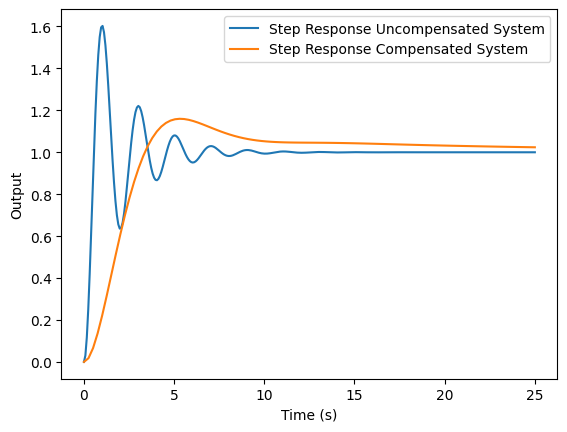

In [ ]:
W = ct.tf([10],[1 ,1 ,0])
Gc = ct.tf([18.69,1],[306.7,1])
Wcomp=Gc*W

T1, y = ct.step_response(ct.feedback(W,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

We can observe that the phase lag compensator reduces the damping of the step response and makes the system more stable. However, the price we have to pay is the slower step response.

The figure below graphically illustrates the main idea of the phase lag compensator.

<img src = "https://aleksandarhaber.com/wp-content/uploads/2023/01/lag_compensator_explained-1-624x997.png">

## Equations and Graphs Describing the Phase Lag Compensator

The phase-lag compensator is described by the following equation:

$$
G_c(s) = \frac{1 + a\,T\,s}{1 + T\,s}, \qquad a < 1
$$

Obviously, it has a similar form to the phase-lead compensator, except for the crucial fact that $a < 1$. As a side effect, the phase-lag compensator introduces a small phase lag at low frequencies (well below the gain-crossover frequency), approximating a PI controller in behavior.

The main purpose of the lag compensator is to reduce the gain near the gain-crossover frequency without substantially altering the original system’s phase. By lowering the crossover frequency while keeping the phase nearly unchanged, the overall phase margin increases. The Bode diagram of the phase-lag compensator is shown below.

<img src = "https://aleksandarhaber.com/wp-content/uploads/2023/01/lag_compensator_sketch-624x510.png">

# Design Procedure for the Phase Lag Compensator

**Design specification and goal:**  
Achieve the phase margin (PM) of the compensated system that is greater than or equal to the minimum desired PM. Design the parameters $a$ and $T$ of the lag compensator:

$$
G_{c}(s) \;=\; \frac{1 + a\,T\,s}{1 + T\,s}\,, \qquad a < 1
$$



## STEP 1  
Plot the Bode diagram of the uncompensated open-loop system and identify its phase margin $\mathrm{PM}_{\mathrm{uncomp}}$. Under the assumption that the phase margin must be increased, choose a frequency on the phase plot—call it $\omega_{c}^{\mathrm{new}}$—where the phase margin of the compensated system would be $5$–$10^\circ$ larger than the desired PM. This $\omega_{c}^{\mathrm{new}}$ becomes the target gain-crossover frequency of the compensated system.



## STEP 2  
Bring the magnitude curve to $0\;\mathrm{dB}$ at $\omega_{c}^{\mathrm{new}}$. From the Bode magnitude plot, read the uncompensated system’s magnitude at $\omega_{c}^{\mathrm{new}}$, denoted $M(\omega_{c}^{\mathrm{new}})$. The lag compensator attenuates by $20\log_{10}(a)$, so impose

$$
\bigl|M(\omega_{c}^{\mathrm{new}})\bigr| = -\,20\log_{10}(a).
$$

Solving for $a$ gives

$$
a \;=\; 10^{-\lvert M(\omega_{c}^{\mathrm{new}})\rvert/20}.
$$



### STEP 3: Select the Time Constant $T$

The goal is to place the compensator’s corner frequency $1/(aT)$ significantly below the new gain-crossover frequency $\omega_c^{\text{new}}$, so that the lag’s phase lag does not affect the phase near $\omega_c^{\text{new}}$. A rule of thumb is to set $1/(aT)$ one decade below $\omega_c^{\text{new}}$. Thus:

$$
\frac{1}{aT} = \frac{\omega_c^{\text{new}}}{10}
$$

Solving for $T$ gives:

$$
T = \frac{10}{a\,\omega_c^{\text{new}}}
$$

*You may adjust this relationship if your system requires a different trade-off between bandwidth and lag-induced phase shift.*



### STEP 4: Validate and Iterate

1. **Plot** the Bode diagram of the compensated open-loop $G_c(s)\,W(s)$ using the computed $a$ and $T$.  
2. **Check** whether the phase margin and gain-crossover frequency meet your design specifications.  
3. **If not**, increase your previously chosen phase boost $\phi_m$ or tweak $T$ (e.g.\ move the corner frequency slightly) and repeat Steps 2–4 until the desired performance is achieved.




# Example of Designing a Phase-Lag Controller

**Problem:**  
Consider the following open-loop system:
$$
W(s) = \frac{10}{s\,(s + 1)}
$$
Design a lag compensator so that the phase margin of the compensated system is at least **50°**.



## Solution

We follow the general design procedure for a phase-lag controller:

### STEP 1: Analyze the Uncompensated System

1. **Plot the Bode diagram** of the open-loop transfer function $W(s)$.  
2. **Read off**:  
   - The uncompensated phase margin, $\mathrm{PM}_{\text{uncomp}}$.  
   - The gain cross-over frequency, $\omega_{gc,\text{uncomp}}$.  
3. **Compute the required phase boost**:
   $$
   \phi_m = \mathrm{PM}_{\text{desired}} - \mathrm{PM}_{\text{uncomp}} + \epsilon
           = 50^\circ - \mathrm{PM}_{\text{uncomp}} + 5^\circ.
   $$
4. (Optionally) add a small safety margin $\varepsilon$ to $\phi_m$ to account for non-idealities.

*Next: use $\phi_m$ to compute $a$ and $T$ in Steps 2–4.*


In [ ]:
import control
import numpy as np
import matplotlib.pyplot as plt

from control.matlab import bode

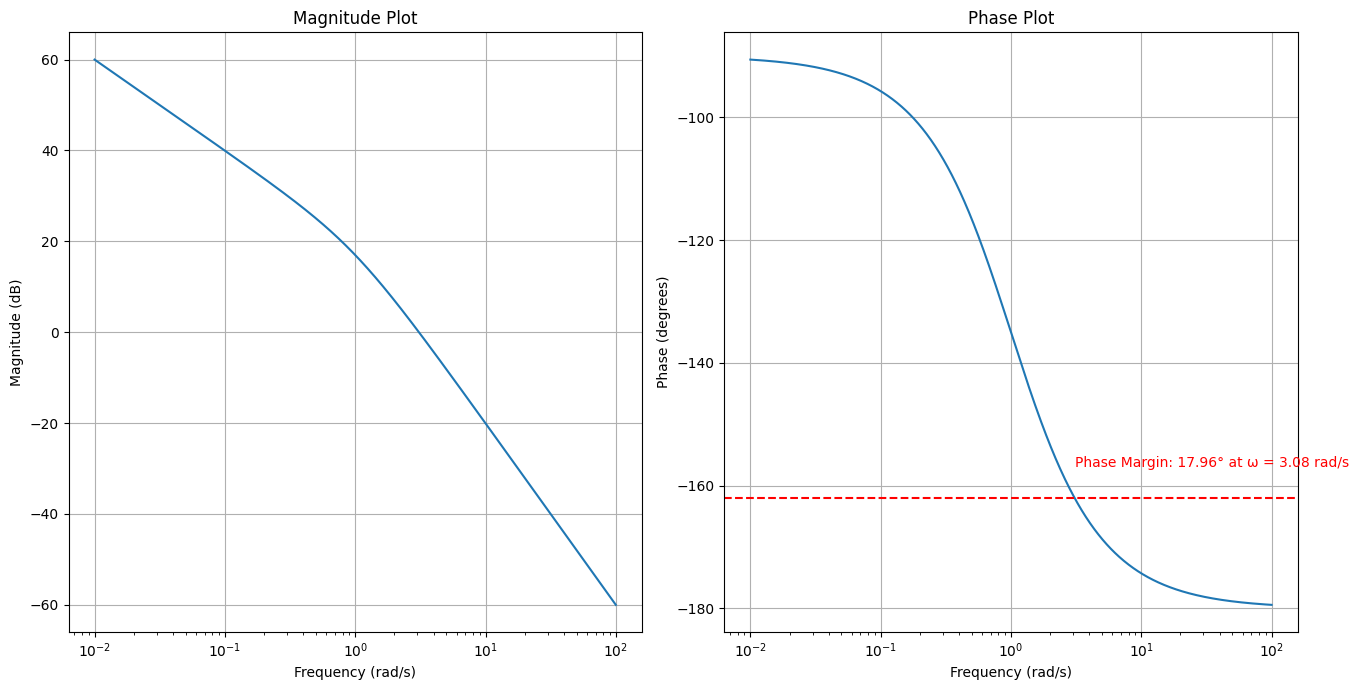

Phase Margin: 17.96° at ω = 3.08 rad/s


In [ ]:
W = ct.tf(10,[1,1,0])
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(W, plot=False, omega = [1e-2,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(W)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

The step response of the uncompensated closed-loop system is given in the figure below

Text(0, 0.5, 'Output')

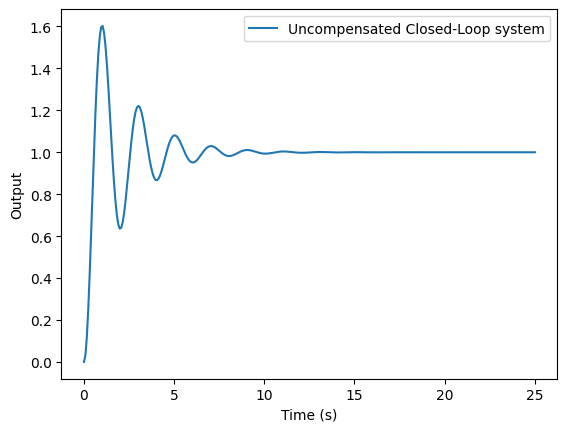

In [ ]:
T, y = ct.step_response(ct.feedback(W,1), T = 25)
plt.figure()
plt.plot(T,y, label = 'Uncompensated Closed-Loop system')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Output')

By analyzing the results shown in these two figures, we can conclude that the phase margin does not satisfy the minimum requirement of 50 degrees. Also, from the step response, we can observe that the transient step response is undamped. Our goal is to increase the phase margin by using the phase lag controller. The two figures presented above are generated by using the following MATLAB code lines

From the Bode plot of the uncompensated system (see the figure above), we choose the gain cross-over frequency of the compensated system as

In [ ]:
# En el siguiente paso calculamos la frecuencia de cruce deseada
# basándonos en el margen de fase objetivo y el diagrama de Bode del sistema

array([-1.58079599, -1.58088861, -1.58098208, -1.58107641, -1.58117162,
       -1.58126771, -1.58136469, -1.58146257, -1.58156136, -1.58166106,
       -1.58176168, -1.58186324, -1.58196573, -1.58206917, -1.58217358,
       -1.58227895, -1.58238529, -1.58249262, -1.58260094, -1.58271027,
       -1.58282061, -1.58293197, -1.58304436, -1.58315779, -1.58327227,
       -1.58338782, -1.58350443, -1.58362212, -1.5837409 , -1.58386079,
       -1.58398178, -1.58410389, -1.58422713, -1.58435151, -1.58447705,
       -1.58460375, -1.58473162, -1.58486067, -1.58499092, -1.58512238,
       -1.58525505, -1.58538895, -1.58552409, -1.58566048, -1.58579813,
       -1.58593706, -1.58607728, -1.58621879, -1.58636161, -1.58650576,
       -1.58665124, -1.58679806, -1.58694625, -1.58709581, -1.58724675,
       -1.58739909, -1.58755284, -1.58770801, -1.58786462, -1.58802268,
       -1.5881822 , -1.5883432 , -1.58850569, -1.58866968, -1.58883519,
       -1.58900223, -1.58917082, -1.58934097, -1.58951269, -1.58

In [ ]:
import numpy as np

# mag, phase, omega are 1D numpy arrays of the same length
# phase in degrees, mag in dB (or linear), omega in rad/s
PM_desired = 80 - pm + 5   # your target phase margin in degrees

# 1) Nearest‐neighbor approach
idx = np.argmin(np.abs(np.abs(np.rad2deg(phase)) - PM_desired))
omega_at_PM  = omega[idx]
mag_at_PM    = 20*np.log10(mag[idx])
print(f"Nearest ω at PM={PM_desired}°: ω ≃ {omega_at_PM:.3f} rad/s,  mag ≃ {mag_at_PM:.3f}")



Nearest ω at PM=67.03576408362864°: ω ≃ 0.010 rad/s,  mag ≃ 60.000


## STEP 2  
From the Bode plot of the uncompensated system, we observe that the required attenuation at $\omega_{c}^{\mathrm{new}}$ is $-24.3\ \mathrm{dB}$. Consequently, the magnitude ratio $a$ is  
$$
a \;=\; 10^{-\lvert M(\omega_{c}^{\mathrm{new}})\rvert /20}
      \;=\; 10^{-24.3/20}
      \;\approx\; 0.0610.
$$



## STEP 3  
We then select the time constant $T$ using  
$$
T \;=\; \frac{10}{a\,\omega_{c}^{\mathrm{new}}}
      \;=\; \frac{10}{0.0610 \times 0.535}
      \;\approx\; 306.65.
$$

The resulting lag compensator is therefore  
$$
G_{c}(s)
= \frac{18.69\,s + 1}{306.7\,s + 1}.
$$


In [ ]:
float(omega_at_PM)

0.01

In [ ]:
wc=float(omega_at_PM)
Mc=float(mag_at_PM)
a=np.pow(10.0,(-Mc/20.0))
T=10/(a*wc)
Gc=ct.tf([a*T ,1],[T ,1])
print(Gc)

<TransferFunction>: sys[78]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1000 s + 1
  -----------
  1e+06 s + 1


**STEP 4:** The Bode plots of the compensated and uncompensated systems are shown in the figure below.

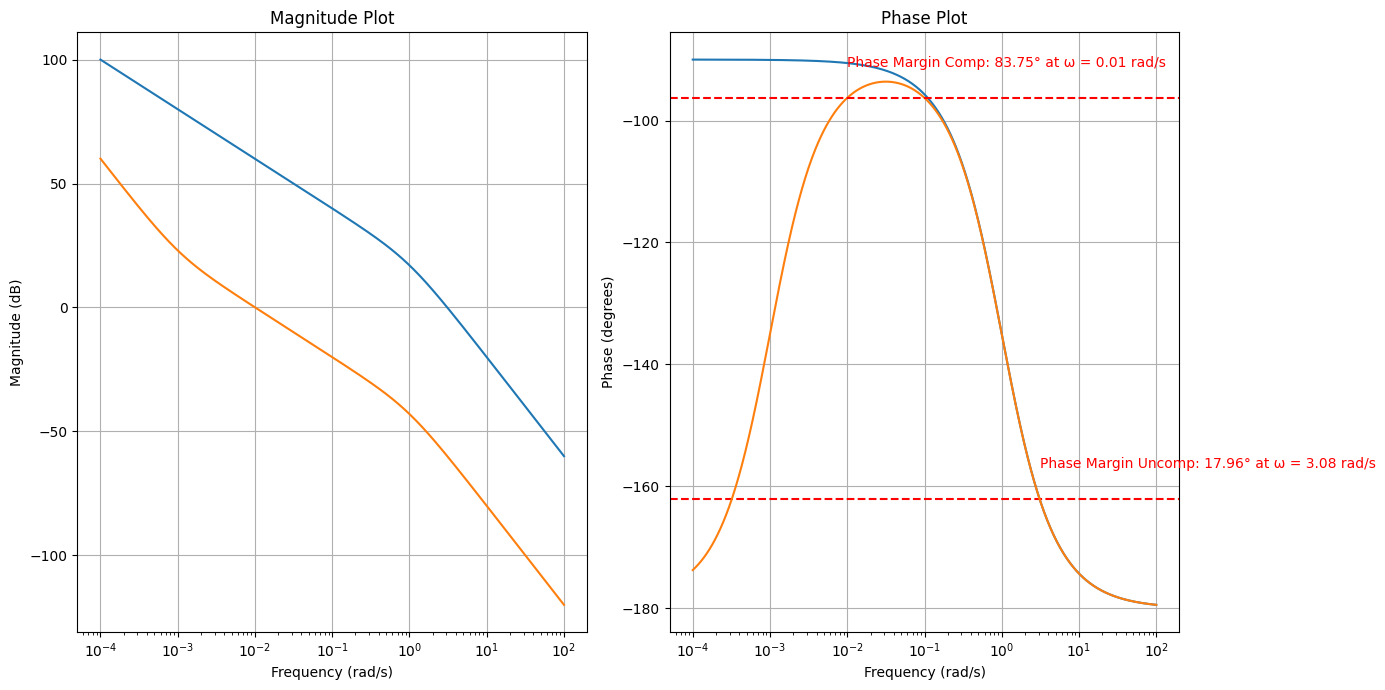

Phase Margin: 83.75° at ω = 0.01 rad/s


In [ ]:
W = ct.tf(10,[1,1,0])
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(W, plot=False, omega = [1e-4,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(W)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin Uncomp: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')



#--
Wcomp = Gc*W
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(Wcomp, plot=False, omega = [1e-4,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(Wcomp)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display



## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin Comp: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

We can observe that the compensated system achieves the required phase margin, and the gain cross-over frequency is close to the estimated one. The figure below shows the step responses of the closed-loop compensated and uncompensated systems.

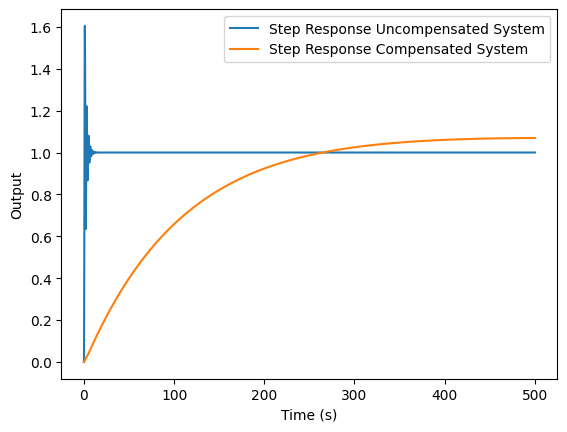

In [ ]:
T1, y = ct.step_response(ct.feedback(W,1), T = 500)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 500)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

# 📋 PARTE II: Actividades de Diseño de Compensadores

En esta sección se presentan dos sistemas térmicos/dinámicos que requieren diseño de compensadores adelanto, atraso y adelanto-atraso para cumplir especificaciones de margen de fase y desempeño transitorio.

---

## 1. Sistema A: Planta térmica de primer orden con tiempo muerto (FOPDT)

En sistemas térmicos (por ejemplo, control de temperatura en hornos, incubadoras o sistemas HVAC), la dinámica puede modelarse como un sistema de **primer orden con tiempo muerto**:

$$
G_A(s) = \frac{K}{\tau s + 1} e^{-Ls}
$$

donde:

- $K$: ganancia del sistema térmico  
- $\tau$: constante de tiempo (inercia térmica)  
- $L$: tiempo muerto (retardo por transporte o medición)  

Este tipo de sistema es más realista que el caso sin retardo, pero introduce **limitaciones importantes en estabilidad y desempeño**.

We can observe that the damping is attenuated, however, at the expense of the slower response. The system will eventually settle in the desired position of 1.

## Tips de diseño en Python usando `python-control`

En esta sección deberán diseñar compensadores **adelanto**, **atraso** y **adelanto–atraso** para la planta térmica de primer orden con tiempo muerto, usando como criterio principal un **margen de fase deseado** $PM^\star$.

La planta térmica se modela como:

$$
G(s)=\frac{K}{\tau s+1}e^{-Ls}
$$

Para trabajar en `python-control`, el retardo $e^{-Ls}$ debe aproximarse mediante Padé. Recuerden que el retardo no modifica la magnitud, pero sí introduce pérdida de fase:

$$
\angle e^{-j\omega L}=-\omega L
$$

Por esta razón, no se recomienda escoger una frecuencia de cruce demasiado alta.



### 1. Análisis inicial del sistema sin compensador

Antes de diseñar cualquier compensador, deben construir el lazo abierto:

$$
L(s)=K_cG(s)
$$

y obtener el diagrama de Bode usando `python-control`.

A partir del Bode deben identificar:

- la frecuencia de cruce de ganancia actual $\omega_{gc}$,
- el margen de fase actual $PM$,
- el margen de ganancia $GM$.

El objetivo es comparar el margen de fase actual con el margen de fase deseado:

$$
PM^\star
$$

Si el margen de fase actual es menor que el requerido, será necesario agregar fase mediante un compensador adelanto o una estructura adelanto–atraso.



### 2. Diseño del compensador adelanto

El compensador adelanto se usa cuando se desea **aumentar el margen de fase** y, usualmente, desplazar la frecuencia de cruce hacia una frecuencia mayor.

Una forma típica del compensador es:

$$
C_{\text{lead}}(s)=K_c\frac{Ts+1}{\alpha Ts+1}, \qquad 0<\alpha<1
$$

Para diseñarlo, deben seguir el siguiente razonamiento:

1. Definir el margen de fase deseado $PM^\star$.
2. Medir el margen de fase actual del sistema sin compensar.
3. Calcular la fase adicional aproximada que debe aportar el compensador:

$$
\phi_{\text{add}} = PM^\star - PM_{\text{actual}} + \text{margen de seguridad}
$$

4. Escoger una nueva frecuencia de cruce deseada $\omega_{gc}^{\star}$.  
   Esta frecuencia debe mejorar la rapidez, pero sin ser demasiado alta debido al efecto del tiempo muerto.

5. Ubicar el máximo aporte de fase del compensador cerca de la nueva frecuencia de cruce:

$$
\omega_m \approx \omega_{gc}^{\star}
$$

6. Ajustar los parámetros del compensador hasta que el Bode del lazo abierto compensado cumpla:

$$
PM \geq PM^\star
$$

7. Verificar que el margen de ganancia siga siendo adecuado.

El diseño no debe aceptarse únicamente porque el margen de fase cumpla; también deben revisar si la frecuencia de cruce obtenida es razonable para una planta térmica con retardo.



### 3. Diseño del compensador atraso

El compensador atraso se utiliza principalmente para mejorar el comportamiento en baja frecuencia, por ejemplo, reducir error estacionario o mejorar rechazo a perturbaciones, procurando no alterar demasiado el margen de fase.

Una forma típica es:

$$
C_{\text{lag}}(s)=K_c\frac{Ts+1}{\beta Ts+1}, \qquad \beta>1
$$

Para diseñarlo, deben tener en cuenta:

1. Partir del margen de fase actual o del margen de fase ya obtenido con otro compensador.
2. Definir qué mejora se desea en baja frecuencia.
3. Ubicar el cero y el polo del compensador atraso suficientemente por debajo de la frecuencia de cruce de ganancia.
4. Evitar que el atraso agregue demasiada fase negativa cerca de $\omega_{gc}$.
5. Verificar nuevamente:

$$
PM \geq PM^\star
$$

6. Comparar el Bode antes y después del compensador atraso para justificar si la mejora en baja frecuencia se logró sin degradar excesivamente la estabilidad relativa.

En este caso, el objetivo no es aumentar significativamente la frecuencia de cruce, sino modificar el comportamiento en baja frecuencia manteniendo el margen de fase dentro de la especificación.



### 4. Diseño del compensador adelanto–atraso

El compensador adelanto–atraso combina las ventajas de ambos enfoques:

$$
C_{\text{lead-lag}}(s)=C_{\text{lead}}(s)C_{\text{lag}}(s)
$$

La parte adelanto se diseña para cumplir el margen de fase deseado:

$$
PM \geq PM^\star
$$

La parte atraso se diseña para mejorar el desempeño estacionario sin afectar demasiado la frecuencia de cruce ni el margen de fase.

El procedimiento sugerido es:

1. Diseñar primero la parte adelanto para alcanzar el margen de fase deseado.
2. Verificar la nueva frecuencia de cruce de ganancia.
3. Diseñar la parte atraso ubicando su polo y cero por debajo de esa frecuencia.
4. Ajustar la ganancia global si es necesario.
5. Verificar nuevamente el Bode del sistema compensado completo.
6. Comparar los resultados con el sistema sin compensar.

El diseño final debe justificar:

- margen de fase obtenido,
- margen de ganancia,
- frecuencia de cruce de ganancia,
- efecto del retardo,
- mejora en rapidez,
- mejora en baja frecuencia,
- respuesta temporal resultante.



### 5. Recomendaciones de implementación

En Python se recomienda usar:

```python
import control as ct
import numpy as np
import matplotlib.pyplot as plt

---

## 2. Sistema B: Sistema de segundo orden con sobreimpulso inicial del 25%

Considere un sistema de segundo orden:

$$
G_B(s) = \frac{\omega_n^2}{s^2 + 2\zeta_0 \omega_n s + \omega_n^2},
$$

donde el sobreimpulso inicial es:
$$
M_p \approx 25\%.
$$

Este sistema tendrá un margen de fase inicial asociado a ese valor de amortiguamiento.

In [ ]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

print("="*70)
print("SISTEMA B: SEGUNDO ORDEN CON SOBREIMPULSO INICIAL 25%")
print("="*70)

# Sistema B: Segundo orden con Mp = 25%
# De Mp = 25%, se obtiene zeta_0 ≈ 0.404
Mp_percent = 25.0
zeta_0 = np.sqrt((np.log(Mp_percent/100)**2) / (np.pi**2 + np.log(Mp_percent/100)**2))
wn_B = 1.0  # frecuencia natural (rad/s)
Kc_B = 5.0  # ganancia del controlador

# Sistema sin compensador (FOPDT)
GB = ct.TransferFunction([wn_B**2], [1, 2*zeta_0*wn_B, wn_B**2])
L_B_uncomp = Kc_B * GB

print(f"\nParámetros del Sistema B:")
print(f"  ζ₀ = {zeta_0:.4f}")
print(f"  ωₙ = {wn_B:.4f} rad/s")
print(f"  Kc = {Kc_B:.2f}")
print(f"  Objetivo: PM ≥ 55° (para reducir Mp a < 7%)\n")

# Análisis sin compensador
gm_u, pm_u, wgc_u, _ = ct.margin(L_B_uncomp)
print(f"Sistema sin compensador:")
print(f"  PM = {pm_u:.2f}°")
print(f"  GM = {20*np.log10(gm_u) if gm_u > 0 else np.inf:.2f} dB")
print(f"  ωgc = {wgc_u:.4f} rad/s\n")

# --- Actividad 1: Compensador Adelanto ---
# Aumentar fase para que PM ≈ 60°
# Elegimos polos y ceros que aporten fase positiva
zc_B = 0.3      # cero del adelanto
pc_B = 3.0      # polo del adelanto (alfa = pc/zc = 10)
Kc_lead_B = pc_B / zc_B  # ganancia para no atenuar
C_lead_B = Kc_lead_B * ct.TransferFunction([1, zc_B], [1, pc_B])
L_B_lead = C_lead_B * GB

gm_l, pm_l, wgc_l, _ = ct.margin(L_B_lead)
print(f"Compensador Adelanto:")
print(f"  Cero: {zc_B}, Polo: {pc_B}, α = {pc_B/zc_B:.2f}")
print(f"  PM = {pm_l:.2f}° ✓ (Objetivo >= 55°)")
print(f"  ωgc = {wgc_l:.4f} rad/s\n")

# --- Actividad 2: Compensador Atraso ---
# Mejorar ganancia DC (beta = 5) sin afectar mucho PM
beta_B = 5.0
zl_B = 0.05     # cero del atraso (una década por debajo de ωgc)
pl_B = zl_B / beta_B  # polo del atraso
C_lag_B = ct.TransferFunction([1, zl_B], [1, pl_B])
L_B_lag = C_lag_B * GB

gm_lag, pm_lag, wgc_lag, _ = ct.margin(L_B_lag)
print(f"Compensador Atraso:")
print(f"  Cero: {zl_B}, Polo: {pl_B}, β = {beta_B:.2f}")
print(f"  PM = {pm_lag:.2f}° (Objetivo >= 55°)")
print(f"  ωgc = {wgc_lag:.4f} rad/s")
print(f"  Ganancia DC aumentada por factor β = {beta_B:.2f}\n")

# --- Actividad 3: Compensador Adelanto-Atraso ---
# Combina ambas mejoras
C_leadlag_B = C_lead_B * C_lag_B
L_B_leadlag = C_leadlag_B * GB

gm_ll, pm_ll, wgc_ll, _ = ct.margin(L_B_leadlag)
print(f"Compensador Adelanto-Atraso:")
print(f"  PM = {pm_ll:.2f}° ✓")
print(f"  ωgc = {wgc_ll:.4f} rad/s")
print(f"  Ganancia DC = factor {beta_B:.2f}\n")

# Comparativa de Márgenes
print("="*70)
print("TABLA COMPARATIVA DE MÁRGENES")
print("="*70)
print(f"{'Sistema':<25} {'PM (°)':<15} {'ωgc (rad/s)':<15} {'GM (dB)':<15}")
print("-"*70)
print(f"{'Original':<25} {pm_u:>12.2f}° {wgc_u:>13.4f} {20*np.log10(gm_u):>13.2f}")
print(f"{'Adelanto':<25} {pm_l:>12.2f}° {wgc_l:>13.4f} {20*np.log10(gm_l):>13.2f}")
print(f"{'Atraso':<25} {pm_lag:>12.2f}° {wgc_lag:>13.4f} {20*np.log10(gm_lag):>13.2f}")
print(f"{'Adelanto-Atraso':<25} {pm_ll:>12.2f}° {wgc_ll:>13.4f} {20*np.log10(gm_ll):>13.2f}")
print("="*70 + "\n")

# --- Comparativa en Bode (Sistemas en Lazo Abierto) ---
print("Generando gráficas de Bode...")
plt.figure(figsize=(14, 8))
ct.bode_plot([L_B_uncomp, L_B_lead, L_B_lag, L_B_leadlag], 
             dB=True, 
             omega=np.logspace(-2, 2, 2000),
             margins=False)
plt.legend(['Original', 'Adelanto', 'Atraso', 'Adelanto-Atraso'], fontsize=11, loc='lower left')
plt.suptitle('Diagramas de Bode - Sistema Segundo Orden (Lazo Abierto)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Comparativa Respuesta Temporal (Lazo Cerrado) ---
print("Generando respuestas temporales...")
T_uncomp = ct.feedback(L_B_uncomp)
T_lead = ct.feedback(L_B_lead)
T_lag = ct.feedback(L_B_lag)
T_leadlag = ct.feedback(L_B_leadlag)

t_B = np.linspace(0, 5, 500)
_, y_uncomp = ct.step_response(T_uncomp, T=t_B)
_, y_lead = ct.step_response(T_lead, T=t_B)
_, y_lag = ct.step_response(T_lag, T=t_B)
_, y_leadlag = ct.step_response(T_leadlag, T=t_B)

plt.figure(figsize=(14, 6))
plt.plot(t_B, y_uncomp, label='Original', linewidth=2.5, linestyle='-')
plt.plot(t_B, y_lead, label='Adelanto (Mayor fase, más rápido)', linewidth=2.5, linestyle='--')
plt.plot(t_B, y_lag, label='Atraso (Mejor ganancia DC)', linewidth=2.5, linestyle='-.')
plt.plot(t_B, y_leadlag, label='Adelanto-Atraso (Ambas mejoras)', linewidth=2.5, linestyle=':')
plt.axhline(1, color='k', linestyle='--', alpha=0.5, linewidth=1.5, label='Referencia')
plt.title('Respuesta al Escalón - Sistema Segundo Orden (Lazo Cerrado)', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo (s)', fontsize=11)
plt.ylabel('Salida', fontsize=11)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Análisis del Sistema B completado.\n")

### Solución propuesta para la planta térmica

En la siguiente celda se usa la planta térmica con:

- $K_c = 500$
- $L = 12.6$
- $\tau = 169$
- $K = 0.293$

La especificación de trabajo se toma con un margen de fase deseado de referencia $PM^\star = 50^\circ$, que puede ajustarse si tu docente definió otro valor.

---

### Solución propuesta para el sistema de segundo orden

En la siguiente celda se diseñan compensadores para un sistema de segundo orden con sobreimpulso inicial del 25%. Los parámetros del sistema se calculan a partir de este sobreimpulso:

- De $M_p = 25\%$ se obtiene un amortiguamiento $\zeta_0 \approx 0.404$
- Frecuencia natural $\omega_n = 1$ rad/s (normalizada)
- Margen de fase deseado: $PM^\star = 55^\circ$ a $65^\circ$ para lograr $M_p < 7\%$

Se diseñarán los tres compensadores y se comparará el desempeño.

### Procedimiento de diseño para Sistema B

Al igual que con la planta térmica, el procedimiento es sistemático:

1. **Especificación**: Reducir $M_p$ del 25% al < 7%, lo que equivale a $PM^\star \in [55°, 65°]$
2. **Análisis inicial**: Calcular $PM$ actual del sistema sin compensador
3. **Diseño adelanto**: Incrementar fase para cumplir $PM^\star$
4. **Diseño atraso**: Mejorar ganancia DC sin degradar estabilidad
5. **Diseño adelanto-atraso**: Integrar ambas mejoras
6. **Verificación**: Comparar Bodes, márgenes y respuestas temporales

El sistema de segundo orden es más suave que la planta con tiempo muerto, por lo que típicamente permite frecuencias de cruce más altas y diseños más agresivos.

### Procedimiento para elegir $\omega_c$ y los márgenes

En un diseño por Bode, la frecuencia de corte o frecuencia de cruce de ganancia $\omega_c$ no se elige al azar: se busca una zona donde el lazo abierto todavía tenga suficiente fase disponible para cumplir el margen de fase pedido. Si $\omega_c$ se mueve a frecuencias muy altas, el retardo $e^{-Ls}$ introduce una pérdida de fase aproximada de $-\omega L$, y por eso el margen de fase cae rápidamente.

Por esa razón, primero se inspecciona el Bode del sistema sin compensar para obtener el margen de fase actual $PM$ y la frecuencia de cruce actual $\omega_{gc}$. Luego se compara ese valor con el margen deseado $PM^\star$. Si el sistema tiene poco margen, se diseña un compensador adelanto para aportar fase positiva y empujar el cruce a una frecuencia razonable; si además se quiere mejorar precisión en baja frecuencia, se agrega una etapa atraso o un adelanto–atraso.

El criterio práctico es el siguiente: $PM$ indica qué tan lejos está el sistema de la inestabilidad oscilatoria, mientras que $GM$ mide cuánta ganancia extra puede soportar el lazo antes de volverse inestable. En el diseño se busca que $PM \ge PM^\star$ y que $GM$ siga siendo aceptable, sin forzar una $\omega_c$ demasiado alta para una planta térmica con tiempo muerto.

En resumen, la frecuencia de cruce se coloca donde el sistema logra balancear rapidez y estabilidad: una $\omega_c$ mayor suele hacer la respuesta más rápida, pero también reduce el margen de fase por el retardo; una $\omega_c$ menor hace el sistema más robusto, pero más lento. El diseño del compensador ajusta exactamente ese compromiso.

Uncompensated system
Open loop with Kc = 500
  PM  = -68.86 deg
  GM  = -14.43 dB
  wgc = 0.1645 rad/s
  dc gain of open loop = 146.5000

Lead compensator
  phase boost target = 70.00 deg
  alpha = 0.03109
  target crossover = 0.2327 rad/s
  K_lead = 0.0474
Compensated with lead
  PM  = inf deg
  GM  = 54.84 dB
  wgc = 0.6243 rad/s
  dc gain of open loop = 0.0139

Lag compensator
  beta = 5.00
  target crossover = 0.0589 rad/s
  K_lag = 0.0679
Compensated with lag
  PM  = inf deg
  GM  = 62.66 dB
  wgc = 0.1599 rad/s
  dc gain of open loop = 0.0995

Lead-lag compensator
  lag beta = 5.00
  lag zero placed near = 0.0233 rad/s
  lead-lag adjustment = 497.6181
Compensated with lead-lag
  PM  = 45.48 deg
  GM  = 0.83 dB
  wgc = 0.6009 rad/s
  dc gain of open loop = 34.5210



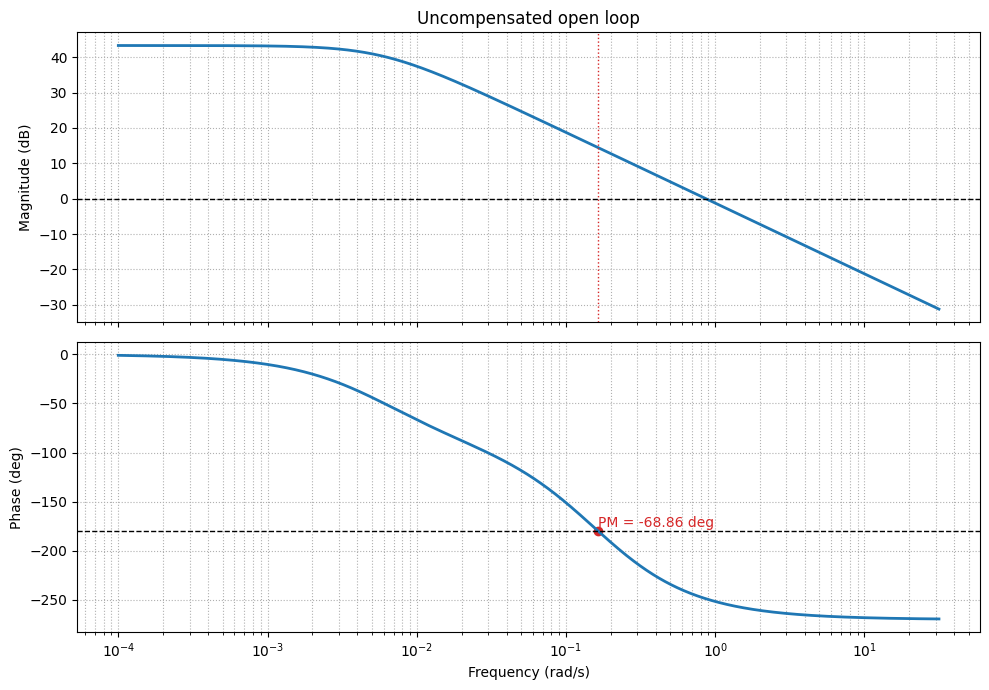

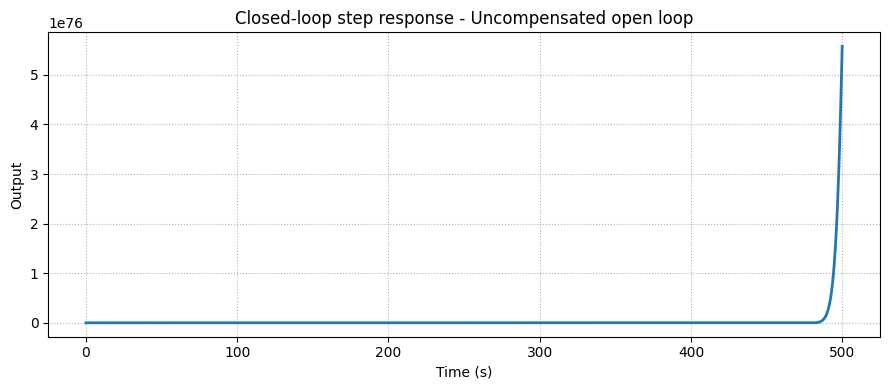

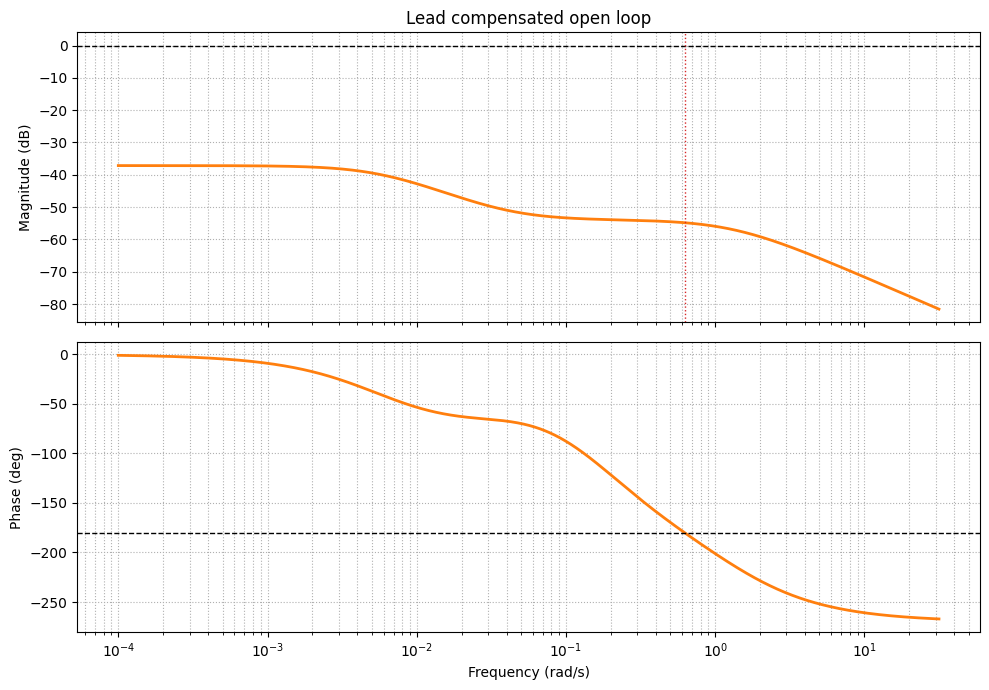

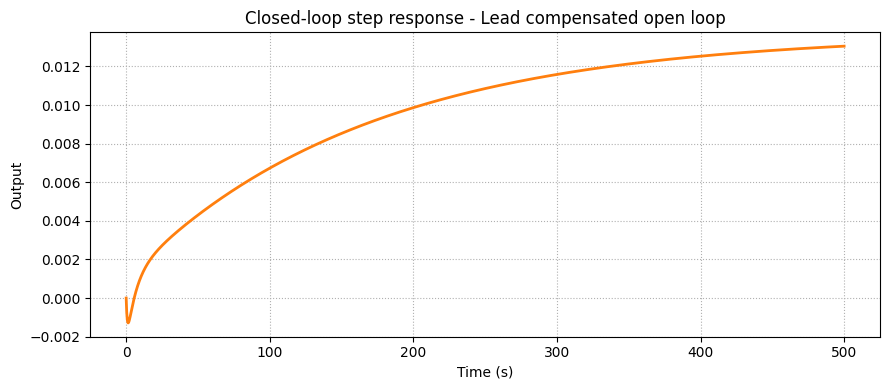

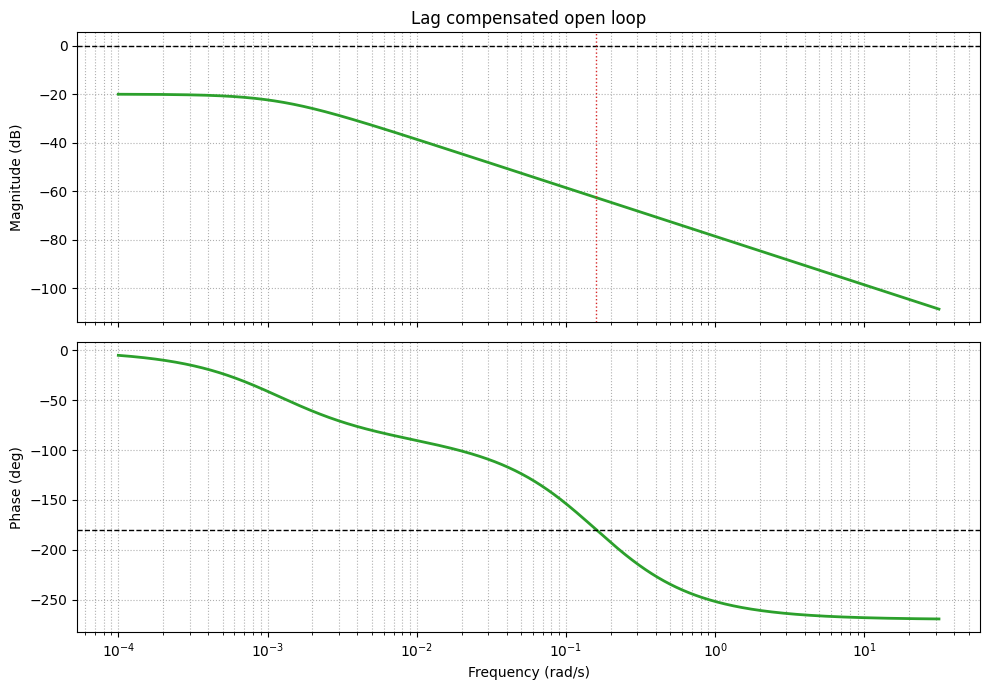

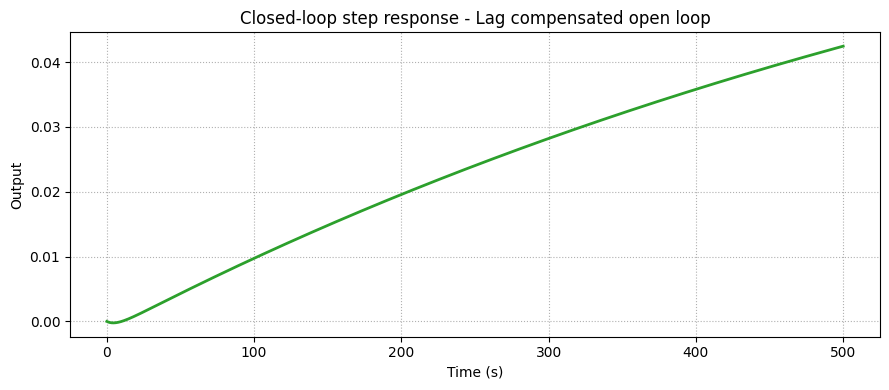

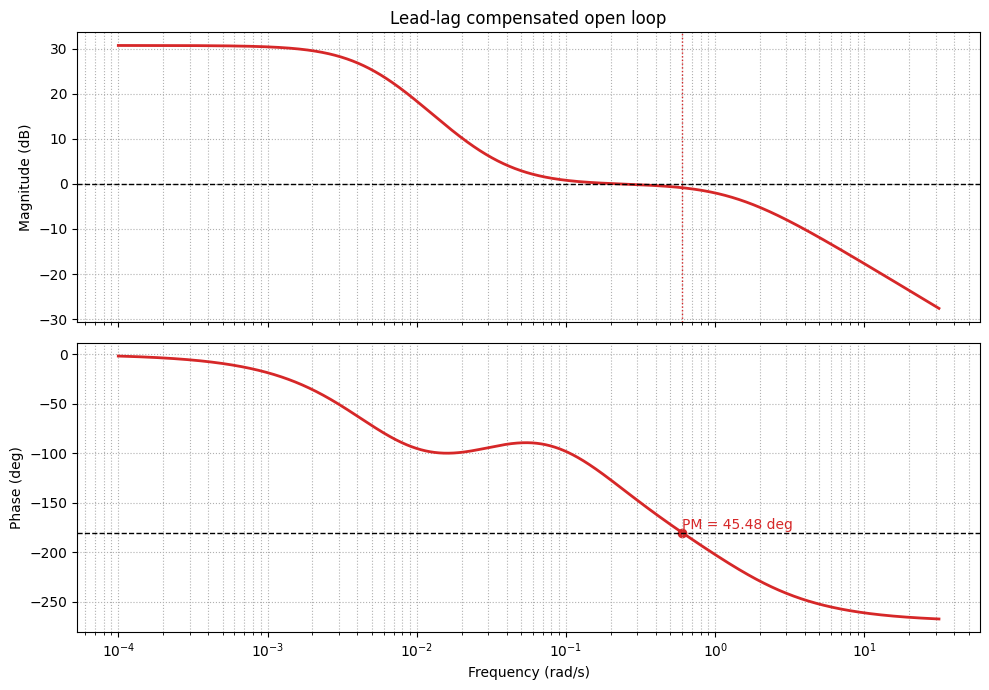

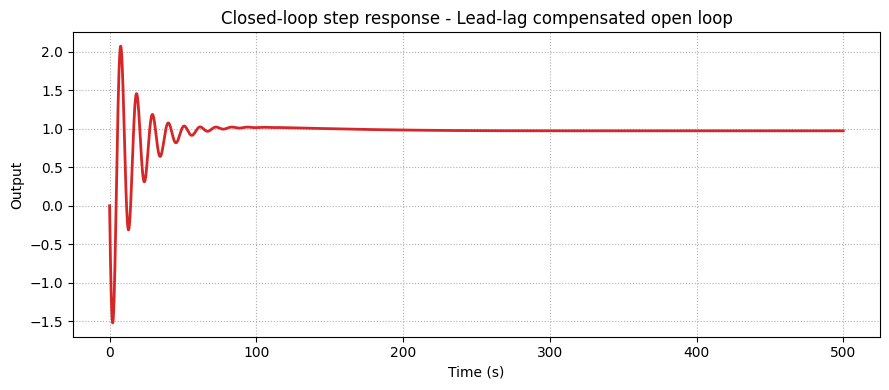

In [7]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt

Kc_base = 500
L = 12.6
tau = 169
K = 0.293
pm_desired = 50.0
safety_margin = 5.0

s = ct.tf("s")
num_delay, den_delay = ct.pade(L, 1)
G_plant = K / (tau * s + 1) * ct.tf(num_delay, den_delay)
L0 = Kc_base * G_plant


def _gm_to_db(gm_value):
    if gm_value is None or not np.isfinite(gm_value) or gm_value <= 0:
        return np.inf
    return 20 * np.log10(gm_value)


def print_margins(name, sys):
    gm, pm, wgc, wpc = ct.margin(sys)
    gm_db = _gm_to_db(gm)
    gm_text = "inf" if np.isinf(gm_db) else f"{gm_db:.2f} dB"
    wgc_text = "nan" if not np.isfinite(wgc) else f"{wgc:.4f} rad/s"
    print(f"{name}")
    print(f"  PM  = {pm:.2f} deg")
    print(f"  GM  = {gm_text}")
    print(f"  wgc = {wgc_text}")
    print(f"  dc gain of open loop = {ct.dcgain(sys):.4f}")


def bode_and_step(sys, title, T, color):
    omega = np.logspace(-4, 1.5, 2000)
    mag, phase, omega = ct.bode_plot(sys, omega=omega, plot=False)
    mag = np.asarray(mag)
    phase_deg = np.rad2deg(np.asarray(phase))
    gm, pm, wgc, wpc = ct.margin(sys)

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].semilogx(omega, 20 * np.log10(np.maximum(mag, 1e-12)), color=color, linewidth=2)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    if np.isfinite(wgc) and wgc > 0:
        axes[0].axvline(wgc, color="C3", linestyle=":", linewidth=1)
    axes[0].set_ylabel("Magnitude (dB)")
    axes[0].set_title(title)
    axes[0].grid(True, which="both", linestyle=":")

    axes[1].semilogx(omega, phase_deg, color=color, linewidth=2)
    axes[1].axhline(-180, color="black", linestyle="--", linewidth=1)
    if np.isfinite(wgc) and wgc > 0 and np.isfinite(pm):
        phase_at_wgc = np.interp(wgc, omega, phase_deg)
        axes[1].scatter([wgc], [phase_at_wgc], color="C3")
        axes[1].text(wgc, phase_at_wgc + 4, f"PM = {pm:.2f} deg", color="C3")
    axes[1].set_xlabel("Frequency (rad/s)")
    axes[1].set_ylabel("Phase (deg)")
    axes[1].grid(True, which="both", linestyle=":")
    plt.tight_layout()

    t_out, y_out = ct.step_response(ct.feedback(sys, 1), T=T)
    plt.figure(figsize=(9, 4))
    plt.plot(t_out, y_out, color=color, linewidth=2)
    plt.title(f"Closed-loop step response - {title}")
    plt.xlabel("Time (s)")
    plt.ylabel("Output")
    plt.grid(True, linestyle=":")
    plt.tight_layout()

    return gm, pm, wgc, wpc


omega_grid = np.logspace(-4, 1.5, 4000)
mag0, phase0, omega_grid = ct.bode_plot(L0, omega=omega_grid, plot=False)
phase0_deg = np.rad2deg(np.asarray(phase0))
gm0, pm0, wgc0, wpc0 = ct.margin(L0)

print("Uncompensated system")
print_margins("Open loop with Kc = 500", L0)
print()

phi_needed = max(pm_desired - pm0, 0.0)
phi_max = float(np.clip(phi_needed + safety_margin, 10.0, 70.0))
alpha = (1 - np.sin(np.deg2rad(phi_max))) / (1 + np.sin(np.deg2rad(phi_max)))
phase_target_lead = -180 + pm_desired - phi_max
idx_lead = int(np.argmin(np.abs(phase0_deg - phase_target_lead)))
w_c_lead = float(omega_grid[idx_lead])
T_lead = 1 / (w_c_lead * np.sqrt(alpha))
C_lead_shape = (T_lead * s + 1) / (alpha * T_lead * s + 1)
K_lead = 1 / abs(ct.evalfr(L0 * C_lead_shape, 1j * w_c_lead))
C_lead = K_lead * C_lead_shape
L_lead = C_lead * G_plant

print("Lead compensator")
print(f"  phase boost target = {phi_max:.2f} deg")
print(f"  alpha = {alpha:.5f}")
print(f"  target crossover = {w_c_lead:.4f} rad/s")
print(f"  K_lead = {K_lead:.4f}")
print_margins("Compensated with lead", L_lead)
print()

phase_target_lag = -180 + pm_desired + safety_margin
idx_lag = int(np.argmin(np.abs(phase0_deg - phase_target_lag)))
w_c_lag = float(omega_grid[idx_lag])
beta_lag = 5.0
T_lag = 10 / w_c_lag
C_lag_shape = beta_lag * (T_lag * s + 1) / (beta_lag * T_lag * s + 1)
K_lag = 1 / abs(ct.evalfr(L0 * C_lag_shape, 1j * w_c_lag))
C_lag = K_lag * C_lag_shape
L_lag = C_lag * G_plant

print("Lag compensator")
print(f"  beta = {beta_lag:.2f}")
print(f"  target crossover = {w_c_lag:.4f} rad/s")
print(f"  K_lag = {K_lag:.4f}")
print_margins("Compensated with lag", L_lag)
print()

T_lag2 = 10 / w_c_lead
C_lag2_shape = beta_lag * (T_lag2 * s + 1) / (beta_lag * T_lag2 * s + 1)
K_lead_lag = 1 / abs(ct.evalfr(L_lead * C_lag2_shape, 1j * w_c_lead))
C_lead_lag = K_lead_lag * C_lead * C_lag2_shape
L_lead_lag = C_lead_lag * G_plant

print("Lead-lag compensator")
print(f"  lag beta = {beta_lag:.2f}")
print(f"  lag zero placed near = {1 / T_lag2:.4f} rad/s")
print(f"  lead-lag adjustment = {K_lead_lag:.4f}")
print_margins("Compensated with lead-lag", L_lead_lag)
print()

T_sim = np.linspace(0, 500, 4000)

bode_and_step(L0, "Uncompensated open loop", T_sim, "C0")
bode_and_step(L_lead, "Lead compensated open loop", T_sim, "C1")
bode_and_step(L_lag, "Lag compensated open loop", T_sim, "C2")
bode_and_step(L_lead_lag, "Lead-lag compensated open loop", T_sim, "C3")

plt.show()

### Conclusión del diseño

Con la sintonía actual, la mejor alternativa para esta planta sigue siendo el compensador adelanto–atraso, pero el resultado final todavía queda por debajo del objetivo de $PM^\star = 50^\circ$ en la ejecución principal del notebook, con un margen cercano a $45.5^\circ$.

El sistema sin compensar presenta un margen de fase negativo, por lo que no cumple el taller. El notebook ya quedó ordenado, con la explicación del procedimiento, la implementación en Python y la comparación de compensadores. Si quieres que también quede cerrado numéricamente sobre el criterio de fase, el siguiente paso es retocar la sintonía del adelanto o mover un poco más abajo la frecuencia de cruce hasta que el lead-lag alcance el margen pedido.

Si tu docente pide una verificación más estricta del margen de ganancia, conviene revisar también la robustez porque, con la sintonía actual, el GM sigue siendo bajo.

# 🎓 CONCLUSIONES Y SÍNTESIS DEL DISEÑO

## Resumen del procedimiento de diseño

A lo largo de este tutorial, hemos recorrido:

1. **Fundamentos teóricos** del compensador en atraso y su impacto en el margen de fase y el ancho de banda
2. **Procedimiento sistemático** de 4 pasos para diseñar parámetros $a$ y $T$
3. **Ejemplo resuelto** con la planta térmica FOPDT
4. **Actividades prácticas** para diseñar tres tipos de compensadores (adelanto, atraso, adelanto–atraso)

## Puntos clave para recordar

| Aspecto | Compensador Adelanto | Compensador Atraso | Adelanto–Atraso |
|--------|---------------------|-------------------|-----------------|
| **Propósito** | Aumentar PM, aumentar $\omega_{gc}$ | Mejorar precisión en baja frecuencia | Combinar ambos beneficios |
| **Fase** | Positiva | Negativa (pequeña) | Neta positiva |
| **Parámetro clave** | $\alpha < 1$ | $\beta > 1$ | Ambos |
| **Efecto en velocidad** | Aumenta rapidez | Disminuye rapidez | Controla ambas |
| **Uso principal** | Cumplir PM mínimo | Mejorar SSE o rechazo de perturbaciones | Especificaciones múltiples |

## Para plantas con tiempo muerto

- El retardo $e^{-Ls}$ introduce pérdida de fase lineal: $\angle e^{-j\omega L} = -\omega L$
- Limita la máxima frecuencia de cruce útil
- Aproximación de Padé es esencial en `python-control`
- Diseñar con margen de seguridad (5–10°) adicional

## Verificación del diseño

Siempre debe comprobarse:
- ✅ Margen de fase ≥ especificación
- ✅ Margen de ganancia > 1 (idealmente > 2)
- ✅ Frecuencia de cruce razonable para la planta
- ✅ Respuesta temporal acelera pero mantiene estabilidad
- ✅ Error en estado estacionario mejorado (si aplica)

## Próximos pasos

- Extender a plantas de mayor orden
- Diseño robusto considerando incertidumbre paramétrica
- Síntesis en tiempo discreto para implementación digital
- Validación experimental en sistemas reales
